# Trend Scout — мультиагентний research-дайджест на LangGraph

**Фінальний проєкт** · курс Generative AI Developer (robot_dreams) · Роман Мицько · липень 2026

Репозиторій: https://github.com/RomanMytsko/trend-scout

**Ідея.** Щотижневий моніторинг agentic-новин — рутина з чіткою декомпозицією: знайти → відібрати → написати → перевірити. Trend Scout автоматизує її мультиагентною системою за патерном **orchestrator–workers**:

```
planner ──> researcher ──> curator ──> writer ──> judge ──> END
   ^            │                        ^          │
   └── replan ──┘ (мало матеріалу)       └─ revise ─┘ (оцінка < 4.0)
```

| Вузол | Тип | Відповідальність |
|---|---|---|
| planner | LLM-агент | декомпозиція тем у пошукові запити (structured output) |
| researcher | tool-воркер | RSS + DuckDuckGo news, дедуплікація; детермінований |
| curator | LLM-агент | ранжування/фільтрація під аудиторію, відсів маркетингу |
| writer | LLM-агент | дайджест у строгому форматі; враховує фідбек judge |
| judge | guardrail + LLM-as-a-judge | URL-allowlist перевірка + рубрика 1–5 за 3 критеріями |

Дві петлі зворотного звʼязку (replan і revise) обмежені лічильниками — гарантія завершення.

In [1]:
%pip install -q git+https://github.com/RomanMytsko/trend-scout.git

Note: you may need to restart the kernel to use updated packages.


## API-ключ

Потрібен лише `OPENAI_API_KEY` (пошук і RSS — безключові). У Colab додай ключ у **Secrets** (іконка 🔑 зліва) або введи нижче.

In [2]:
import os

if not os.environ.get("OPENAI_API_KEY"):
    try:
        from google.colab import userdata
        os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
    except Exception:
        import getpass
        os.environ["OPENAI_API_KEY"] = getpass.getpass("OPENAI_API_KEY: ")

# Мова дайджесту і аудиторія конфігуруються через env (див. .env.example)
os.environ.setdefault("DIGEST_LANGUAGE", "Ukrainian")
os.environ.setdefault("AUDIENCE", "backend Python engineer")
print("OK")

OK


## Візуалізація графа

LangGraph компілює `StateGraph` з умовними переходами — подивимось на нього.

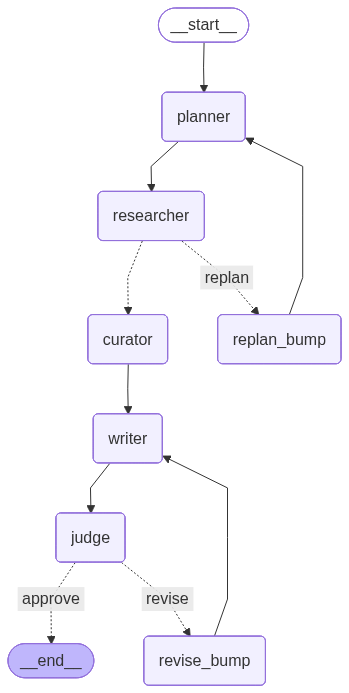

In [3]:
from trend_scout import graph

app = graph.build_graph()

try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print(app.get_graph().draw_mermaid())  # fallback: mermaid-текст

## Запуск пайплайну

Теми можна міняти на свої. Виконання ~1–3 хв: RSS-фіди, кілька пошукових запитів і 4–6 LLM-викликів.

In [4]:
TOPICS = [
    "multi-agent orchestration",
    "MCP and A2A protocols",
    "LangGraph and agent frameworks",
    "context engineering",
]

state = graph.run_digest(TOPICS)

print("--- pipeline events ---")
for event in state["events"]:
    print(" ", event)

--- pipeline events ---
  planner: 6 queries
  researcher: 46 rss + search -> 61 unique items
  curator: picked 5 items
  writer: draft #0 ready
  judge: relevance=5 grounding=5 format=4 avg=4.67


## Оцінка якості (LLM-as-a-judge)

Перед рубрикою LLM-судді спрацьовує **детермінований guardrail**: усі лінки в дайджесті мають входити до allowlist зібраних URL (захист від галюцинованих джерел і prompt injection у сніпетах).

In [5]:
verdict = state["verdict"]
print(f"relevance    : {verdict.relevance}/5")
print(f"grounding    : {verdict.grounding}/5")
print(f"format       : {verdict.format_score}/5")
print(f"average      : {verdict.average:.2f} (поріг 4.0)")
print(f"ревізій      : {state.get('revisions', 0)}")
print(f"replan-ів    : {state.get('replans', 0)}")
print(f"\nфідбек судді: {verdict.feedback}")

relevance    : 5/5
grounding    : 5/5
format       : 4/5
average      : 4.67 (поріг 4.0)
ревізій      : 0
replan-ів    : 0

фідбек судді: The digest is highly relevant to the topics of multi-agent orchestration, MCP and A2A protocols, LangGraph and agent frameworks, and context engineering, and it is well targeted at backend Python engineers. All claims are well grounded in the source items with accurate titles, summaries, and correct URLs. The format mostly follows the required Ukrainian structure with title, intro, and per-item sections including 'Суть', 'Чому важливо', and 'Лінк'. However, the digest is missing an introductory paragraph after the main title, which is required by the instructions. Adding a brief introduction before the first item would improve the format score to perfect.


## Результат — дайджест

In [6]:
from IPython.display import Markdown, display

display(Markdown(state["digest"]))

# Огляд новинок для backend Python-інженерів у сфері агентних систем та оркестрації

## 1. Bad Memory: Evaluating Prompt Injection Risks from Memory in Agentic Systems  
- Суть: Досліджено ризики ін’єкції команд у системах агентів, які зберігають стан у пам’яті між сесіями. Зловмисні інструкції можуть впливати на поведінку агентів через постійні файли пам’яті.  
- Чому важливо: Розуміння цих вразливостей допоможе backend-інженерам будувати безпечні системи з багатьма агентами, що зберігають стан.  
- Лінк: [arXiv](https://arxiv.org/abs/2607.14611v1)  

## 2. Stigmergic Graph Memory: An Environment-Aware Approach for Many-to-Many Multi-Agent Pickup and Delivery  
- Суть: Запропоновано новий підхід Stigmergic Graph Memory для багатокористувацьких систем доставки, який враховує поточний трафік при виборі кінцевих точок. Це покращує планування маршрутів у складних середовищах.  
- Чому важливо: Цей метод корисний для розробки агентних систем, що працюють у реальному часі з динамічним середовищем.  
- Лінк: [arXiv](https://arxiv.org/abs/2607.15182v1)  

## 3. Least privilege for AI agents: Identity, access, and tool binding  
- Суть: Microsoft підкреслює важливість принципу найменших привілеїв для автономних AI-агентів, зокрема через контроль ідентичності, доступу та прив’язки інструментів.  
- Чому важливо: Ці практики є ключовими для безпечного управління доступом і взаємодією між агентами на бекенді.  
- Лінк: [Microsoft Security Blog](https://www.microsoft.com/en-us/security/blog/2026/07/16/least-privilege-for-ai-agents-identity-access-and-tool-binding/)  

## 4. Agentic orchestration: Enterprise AI organizations have a deployment problem, not a platform problem — and most are calling chatbots agents  
- Суть: У статті описано, що основна проблема підприємств — розгортання агентних систем, а не вибір платформи. Anthropic Claude лідирує серед платформ для оркестрації агентів.  
- Чому важливо: Розуміння проблем розгортання допоможе backend-інженерам ефективніше впроваджувати багатокрокові агентні рішення.  
- Лінк: [VentureBeat](https://venturebeat.com/ai/agentic-orchestration-enterprise-ai-organizations-have-a-deployment-problem-not-a-platform-problem-and-most-are-calling-chatbots-agents)  

## 5. Top Python Frameworks for Building Autonomous AI Agents in 2026  
- Суть: Огляд найкращих Python-фреймворків для створення автономних AI-агентів у 2026 році, включно з LangGraph, CrewAI та Microsoft Agent Framework.  
- Чому важливо: Допомагає backend Python-розробникам обрати оптимальні інструменти для побудови та оркестрації агентних систем.  
- Лінк: [Analytics Insight](https://www.analyticsinsight.net/artificial-intelligence/top-python-frameworks-for-building-autonomous-ai-agents-in-2026)

## Зазирнемо всередину: проміжні стани агентів

In [7]:
print("PLAN (planner, structured output):")
print("  reasoning:", state["plan"].reasoning)
for q in state["plan"].queries:
    print("  query:", q)

print(f"\nITEMS (researcher): {len(state['items'])} зібрано, приклади:")
for item in state["items"][:5]:
    print(f"  [{item.source}] {item.title[:80]}")

print("\nCURATION (curator):")
for pick in state["curation"].picks:
    print(f"  #{pick.index} relevance={pick.relevance}: {pick.why_it_matters[:100]}")

PLAN (planner, structured output):
  reasoning: To cover the topics comprehensively for a backend Python engineer, the queries focus on recent developments and practical implementations in multi-agent orchestration, MCP and A2A protocols, LangGraph and agent frameworks, and context engineering. The queries are specific enough to target relevant technical content but broad enough to capture diverse sources from the last week.
  query: multi-agent orchestration frameworks Python 2024
  query: latest MCP protocol updates for agent communication
  query: A2A protocols in multi-agent systems backend
  query: LangGraph agent framework Python integration
  query: context engineering techniques in AI systems 2024
  query: multi-agent orchestration best practices backend development June 2024

ITEMS (researcher): 61 зібрано, приклади:
  [Hacker News (front page)] Mozilla: The state of open source AI
  [Hacker News (front page)] Claude Code: Anatomy of a Misfeature
  [Hacker News (front page)] A

## Висновки

- **Патерн orchestrator–workers** реалізований на LangGraph: LLM-агенти планують/курують/пишуть, детермінований воркер виконує інструменти.
- **Structured outputs (Pydantic)** у кожного агента — жодного парсингу вільного тексту.
- **LLM-as-a-judge** як quality gate з петлею ревізій і порогом 4.0.
- **Guardrails проти prompt injection**: санітизація контенту, явне маркування untrusted-даних у промптах, детермінований URL-allowlist.
- **Надійність** як у бекенд-системах: graceful degradation інструментів, capped retries, event log.

Можливий розвиток: доставка в Telegram, розклад на Celery beat / cron, A2A-інтерфейс для інших агентів.